# D2C Customer Churn Intelligence & Retention API

## Part 2: RFM Segmentation & Retention Strategy

## Objective

The goal of this analysis is to segment customers using the RFM framework and design retention strategies for each segment.

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Loading orders dataset 

orders = pd.read_csv("../data/orders.csv")

In [4]:
# Checking first 5 rows

orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [5]:
# Checking dataset shape

print(orders.shape)

(10009, 10)


In [6]:
# Checking column names

print(orders.columns)

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='str')


In [7]:
# Checking missing values

orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [8]:
# Converting order_date column into datetime format

orders["order_date"] = pd.to_datetime(orders["order_date"])

In [9]:
# Checking data types

orders.dtypes

order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object

In [10]:
# Creating snapshot date

snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2025-11-30 00:00:00


In [11]:
# Creating RFM table

rfm = orders.groupby("customer_id").agg({
    
    "order_date": lambda x: (snapshot_date - x.max()).days,
    
    "order_id": "count",
    
    "gross_amount": "sum"
})

# Renaming columns

rfm.columns = ["Recency", "Frequency", "Monetary"]

# Checking first 5 rows

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
CUST00001,168,6,2955.57
CUST00002,35,3,1713.10
CUST00003,232,1,649.98
CUST00004,192,1,1604.04
CUST00005,11,6,3910.43


In [12]:
# Checking RFM table shape

print(rfm.shape)

# Summary statistics

rfm.describe()

(2400, 3)


,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,106.552083,4.170417,3102.366721
std,103.035447,2.626960,2318.314239
min,1.000000,1.000000,149.000000
25%,23.000000,2.000000,1371.697500
50%,56.000000,4.000000,2621.735000
75%,180.250000,6.000000,4253.452500
max,623.000000,17.000000,27920.050000


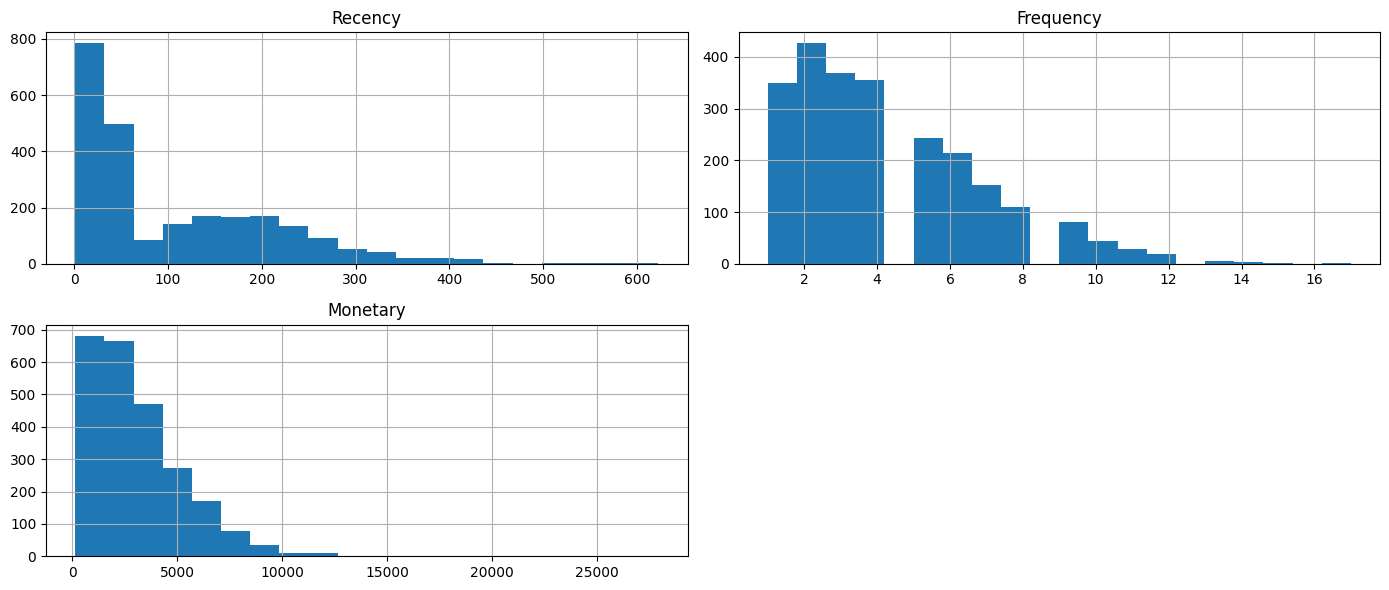

In [13]:
# Plotting RFM distributions

rfm.hist(figsize=(14, 6), bins=20)
plt.tight_layout()
plt.show()

### Observation:
* Most customers have low frequency and monetary values.
* A small number of customers contribute very high spending.
* RFM features are right-skewed.

In [14]:
# Creating RFM scores using quartiles

r_labels = [4,3,2,1]
f_labels = [1,2,3,4]
m_labels = [1,2,3,4]

rfm["R_score"] = pd.qcut(rfm["Recency"], q=4, labels=r_labels)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=f_labels)
rfm["M_score"] = pd.qcut(rfm["Monetary"], q=4, labels=m_labels)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
customer_id,,,,,,
CUST00001,168,6,2955.57,2,3,3
CUST00002,35,3,1713.10,3,2,2
CUST00003,232,1,649.98,1,1,1
CUST00004,192,1,1604.04,1,1,2
CUST00005,11,6,3910.43,4,3,3


In [15]:
# Creating combined RFM score

rfm["RFM_Score"] = (
    
    rfm["R_score"].astype(str) +
    
    rfm["F_score"].astype(str) +
    
    rfm["M_score"].astype(str)
)

# Checking first rows

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customer_id,,,,,,,
CUST00001,168,6,2955.57,2,3,3,233
CUST00002,35,3,1713.10,3,2,2,322
CUST00003,232,1,649.98,1,1,1,111
CUST00004,192,1,1604.04,1,1,2,112
CUST00005,11,6,3910.43,4,3,3,433


In [16]:
# Creating customer segments

def segment_customer(row):

    if row["RFM_Score"] == "444":
        return "Champions"

    elif row["R_score"] == 4:
        return "New Customers"

    elif row["F_score"] == 4:
        return "Loyal Customers"

    elif row["M_score"] == 4:
        return "High Value Customers"

    else:
        return "At Risk Customers"


# Applying segmentation
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Checking first rows
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customer_id,,,,,,,,
CUST00001,168,6,2955.57,2,3,3,233,At Risk Customers
CUST00002,35,3,1713.10,3,2,2,322,At Risk Customers
CUST00003,232,1,649.98,1,1,1,111,At Risk Customers
CUST00004,192,1,1604.04,1,1,2,112,At Risk Customers
CUST00005,11,6,3910.43,4,3,3,433,New Customers


In [17]:
# Checking customer segment distribution

rfm["Segment"].value_counts()

Segment
At Risk Customers       1312
New Customers            448
Loyal Customers          400
Champions                153
High Value Customers      87
Name: count, dtype: int64

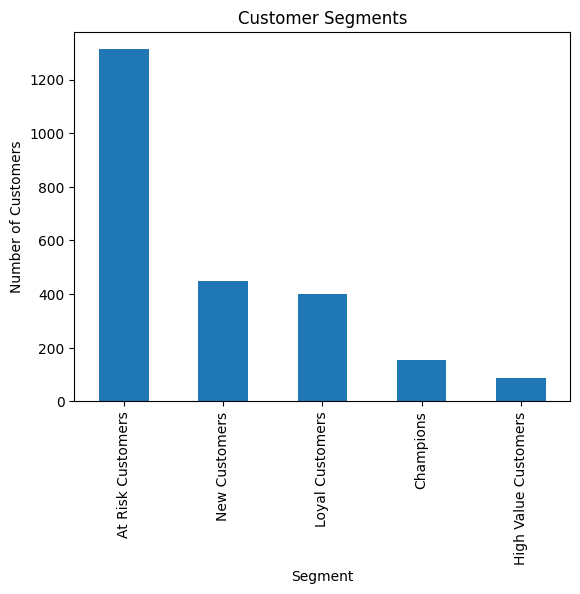

In [18]:
# Visualizing customer segments

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

### RFM Business Insights

* Best Customers are highly valuable and should be retained using loyalty rewards and premium offers.

* Recent Customers purchased recently and can be targeted with personalized recommendations.

* Loyal Customers purchase frequently and may respond well to membership programs.

* Big Spenders contribute high revenue and should receive exclusive benefits.

* At Risk Customers may stop purchasing soon and need re-engagement campaigns.

In [19]:
# Additional Non-RFM Signals

additional_features = orders.groupby("customer_id").agg({
    "returned": "mean",
    "discount_pct": "mean",
    "rating": "mean",
    "delivery_days": "mean"
}).reset_index()

additional_features.columns = [
    "customer_id",
    "return_rate",
    "avg_discount",
    "avg_rating",
    "avg_delivery_days"
]

additional_features.head()

,customer_id,return_rate,avg_discount,avg_rating,avg_delivery_days
0,CUST00001,0.166667,0.363333,3.333333,3.500000
1,CUST00002,0.000000,0.190000,4.333333,3.333333
2,CUST00003,0.000000,0.470000,2.000000,2.000000
3,CUST00004,0.000000,0.160000,2.000000,5.000000
4,CUST00005,0.000000,0.388333,2.333333,5.166667


In [20]:
# Merging additional features with RFM table

rfm = rfm.reset_index()

rfm = rfm.merge(
    additional_features,
    on="customer_id",
    how="left"
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,return_rate,avg_discount,avg_rating,avg_delivery_days
0,CUST00001,168,6,2955.57,2,3,3,233,At Risk Customers,0.166667,0.363333,3.333333,3.500000
1,CUST00002,35,3,1713.10,3,2,2,322,At Risk Customers,0.000000,0.190000,4.333333,3.333333
2,CUST00003,232,1,649.98,1,1,1,111,At Risk Customers,0.000000,0.470000,2.000000,2.000000
3,CUST00004,192,1,1604.04,1,1,2,112,At Risk Customers,0.000000,0.160000,2.000000,5.000000
4,CUST00005,11,6,3910.43,4,3,3,433,New Customers,0.000000,0.388333,2.333333,5.166667


In [21]:
# Checking new columns

rfm.columns

Index(['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score',
       'M_score', 'RFM_Score', 'Segment', 'return_rate', 'avg_discount',
       'avg_rating', 'avg_delivery_days'],
      dtype='str')

In [22]:
# Segment-wise business summary

segment_summary = rfm.groupby("Segment").agg({
    "Monetary": "mean",
    "Frequency": "mean",
    "Recency": "mean",
    "return_rate": "mean",
    "avg_discount": "mean",
    "avg_rating": "mean",
    "avg_delivery_days": "mean"
}).round(2)

segment_summary

,Monetary,Frequency,Recency,return_rate,avg_discount,avg_rating,avg_delivery_days
Segment,,,,,,,
At Risk Customers,1823.02,2.63,152.80,0.08,0.28,3.89,4.45
Champions,6618.74,8.65,11.26,0.07,0.27,3.90,4.53
High Value Customers,5454.06,4.77,151.25,0.06,0.23,3.87,4.55
Loyal Customers,5850.40,7.75,87.80,0.07,0.28,3.85,4.48
New Customers,2737.84,3.85,11.71,0.06,0.27,3.92,4.40


In [23]:
segment_summary.to_csv("../outputs/segment_summary.csv")

In [24]:
import os 
os.listdir("../outputs")

['rfm_final.csv', 'segment_summary.csv']

In [25]:
# Business recommendations

recommendations = {
    "Champions": "Provide VIP rewards, loyalty benefits, and early access offers.",
    "Loyal Customers": "Introduce membership programs and cross-sell premium products.",
    "New Customers": "Send personalized recommendations and onboarding campaigns.",
    "High Value Customers": "Offer exclusive discounts and premium services.",
    "At Risk Customers": "Launch win-back campaigns, coupons, and re-engagement emails."
}

for segment, recommendation in recommendations.items():
    print(f"{segment}: {recommendation}")

Champions: Provide VIP rewards, loyalty benefits, and early access offers.
Loyal Customers: Introduce membership programs and cross-sell premium products.
New Customers: Send personalized recommendations and onboarding campaigns.
High Value Customers: Offer exclusive discounts and premium services.
At Risk Customers: Launch win-back campaigns, coupons, and re-engagement emails.


# Campaign Budget Allocation

## Total Campaign Budget

**$10,000**

## Priority Segment: At Risk Customers

### Why prioritize this segment?

- At Risk Customers are the largest customer segment.
- They have not purchased recently and may churn soon.
- Retaining existing customers is more cost-effective than acquiring new customers.
- Recovering even a small percentage of these customers can significantly increase revenue.

## Proposed Budget Distribution

| Segment | Budget Allocation |
|----------|----------|
| At Risk Customers | $5,000 |
| Loyal Customers | $2,000 |
| Champions | $1,500 |
| New Customers | $1,000 |
| High Value Customers | $500 |

### Expected Outcome

- Reduce customer churn.
- Improve customer retention.
- Increase repeat purchases.
- Strengthen long-term customer loyalty.

In [26]:
# Manual Review Sample

manual_review = rfm.sample(10, random_state=42)

manual_review[[
    "customer_id",
    "Segment",
    "Recency",
    "Frequency",
    "Monetary",
    "return_rate",
    "avg_discount"
]]

,customer_id,Segment,Recency,Frequency,Monetary,return_rate,avg_discount
2037,CUST02038,At Risk Customers,323,3,1941.74,0.0,0.393333
1978,CUST01979,New Customers,21,2,1075.89,0.0,0.240000
855,CUST00856,New Customers,22,2,2859.31,0.0,0.140000
1719,CUST01720,At Risk Customers,50,4,1688.80,0.0,0.432500
2019,CUST02020,At Risk Customers,91,3,2876.52,0.0,0.250000
134,CUST00135,At Risk Customers,394,4,2534.18,0.0,0.290000
1375,CUST01376,New Customers,5,2,1173.88,0.0,0.040000
1711,CUST01712,New Customers,20,2,1445.64,0.0,0.335000
1289,CUST01290,New Customers,2,4,2817.87,0.0,0.225000
1068,CUST01069,At Risk Customers,53,2,3871.47,0.0,0.255000


# Manual Review of 10 Customer IDs

## Customer Reviews

### 1. CUST02038
- Segment: At Risk Customers
- High recency (323 days) indicates inactivity.
- Recommendation: Send win-back offers and personalized discounts.

### 2. CUST01979
- Segment: New Customers
- Recent customer with low frequency.
- Recommendation: Onboarding campaign and product recommendations.

### 3. CUST00856
- Segment: New Customers
- Limited purchase history.
- Recommendation: Encourage second purchase through targeted offers.

### 4. CUST01720
- Segment: At Risk Customers
- High monetary value but not purchasing recently.
- Recommendation: Priority retention outreach.

### 5. CUST02020
- Segment: At Risk Customers
- Moderate spending but declining engagement.
- Recommendation: Re-engagement email campaign.

### 6. CUST00135
- Segment: At Risk Customers
- Very high recency (394 days).
- Recommendation: Strong win-back incentive.

### 7. CUST01376
- Segment: New Customers
- Very recent customer.
- Recommendation: Personalized onboarding experience.

### 8. CUST01712
- Segment: New Customers
- Low purchase frequency.
- Recommendation: Cross-sell and recommendation campaigns.

### 9. CUST01290
- Segment: New Customers
- Recent activity and good monetary value.
- Recommendation: Loyalty enrollment opportunity.

### 10. CUST01069
- Segment: At Risk Customers
- High spending customer at risk of churn.
- Recommendation: Exclusive retention offer and follow-up.

# RFM Business Insights

## Key Findings

- Champions generate the highest revenue and purchase most frequently.
- Loyal Customers show strong repeat purchase behavior.
- High Value Customers contribute significant revenue but purchase less frequently.
- New Customers have high engagement potential.
- At Risk Customers require immediate retention efforts.

## Retention Strategy

| Segment | Strategy |
|----------|----------|
| Champions | VIP rewards and loyalty benefits |
| Loyal Customers | Membership programs |
| New Customers | Personalized recommendations |
| High Value Customers | Exclusive offers |
| At Risk Customers | Win-back campaigns |

In [27]:
rfm.to_csv("../outputs/segments.csv", index=False)

In [28]:
import os
os.listdir("../outputs")

['rfm_final.csv', 'segments.csv', 'segment_summary.csv']

# Conclusion

- At Risk Customers represent the largest segment and should be prioritized for retention campaigns.
- Champions generate the highest revenue and should receive loyalty rewards.
- Loyal Customers demonstrate strong repeat purchase behavior.
- New Customers show potential for future growth and engagement.
- Segment-specific retention strategies can improve customer lifetime value and reduce churn.